# NLP Assignment: Progressive Text Classification Techniques

Dataset: **20 Newsgroups** (20 categories, ~20,000 documents)

Built task by task, following the assignment pipeline exactly.

## **Task 1: Data Preparation**

**Concept:** Before any model can use these posts, we clean the raw text (remove noise, tokenize, lowercase) and create ONE fixed train/validation/test split that every model in this notebook will reuse, so comparisons across models (Task 8) are fair.

In [ ]:
# --- Setup ---
!pip install -q nltk

import re
import string
import nltk
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

STOPWORDS = set(stopwords.words('english'))

### Load the Dataset

We strip `headers`, `footers`, and `quotes` at load time. This removes an obvious shortcut (e.g. the sender's email domain leaking the category) that would let a model "cheat" instead of learning from the actual post content.

In [ ]:
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=42
)

texts = newsgroups.data
labels = newsgroups.target
target_names = newsgroups.target_names

print(f"Total documents: {len(texts)}")
print(f"Number of classes: {len(target_names)}")
print(f"Classes: {target_names}")
print("\nExample raw document:\n", texts[0][:300])

### Preprocessing

**Steps applied (in order):** lowercase → remove punctuation/numbers/extra whitespace → tokenize → remove stop words.

We keep a `clean_text` (string, for BoW/TF-IDF/ANN) and a `tokens` (list, for tokenizer-based models like RNN/embeddings) version, since different models further down the pipeline expect different input shapes.

In [ ]:
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

STOPWORDS = set(stopwords.words('english'))

def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and digits
    text = re.sub(f"[{re.escape(string.punctuation)}0-9]", " ", text)
    # Collapse extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stop words and very short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return tokens

# Apply to all documents
tokenized_docs = [preprocess(t) for t in texts]
clean_texts = [" ".join(tok) for tok in tokenized_docs]

print("Before:", texts[0][:200])
print("\nAfter :", clean_texts[0][:200])

### Train / Validation / Test Split (70 / 15 / 15)

**Why `stratify=labels`:** 20 Newsgroups has a roughly even number of posts per category, but stratifying guarantees the class proportions stay identical across all three sets — important groundwork for Task 8's fair comparison, and it avoids one class being under-represented in the test set by chance.

**Why `random_state=42` everywhere:** using the same seed for every split call, in every task, from here through Task 7, is what makes the assignment's "same split used consistently across all models" requirement actually true.

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# First split: 70% train, 30% temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    clean_texts, labels, test_size=0.30, random_state=RANDOM_STATE, stratify=labels
)

# Second split: split the 30% temp into 15% val, 15% test (i.e. 50/50 of the temp chunk)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(X_train)} ({len(X_train)/len(clean_texts):.1%})")
print(f"Val:   {len(X_val)} ({len(X_val)/len(clean_texts):.1%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(clean_texts):.1%})")

**Checkpoint:** `X_train, X_val, X_test, y_train, y_val, y_test` (plus `target_names`) are now the fixed inputs every later task will build on. We will not re-split the data again anywhere else in this notebook.

# **Task 2: ANN Baseline**

 We vectorize text with TF-IDF (each document becomes a sparse vector scoring words by how distinctive they are, as covered in the theory) and feed that into a simple feedforward neural network. This is our floor — every later model should ideally beat this.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit TF-IDF ONLY on training data, then transform val/test (never fit on val/test - avoids leakage)
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_val_tfidf = tfidf.transform(X_val).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

print("TF-IDF shapes:", X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)

### **Build and Train the ANN**

A simple 2-hidden-layer dense network. Input size = 10,000 (TF-IDF vocabulary), output size = 20 (one softmax score per newsgroup category).

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ann(input_dim, num_classes=20):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

ann_model = build_ann(X_train_tfidf.shape[1])
ann_model.summary()

history_ann = ann_model.fit(
    X_train_tfidf, y_train,
    validation_data=(X_val_tfidf, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)

## **Evaluation**

Confusion matrix, accuracy, precision, recall, and F1 (macro-averaged, since all 20 classes matter equally, not just the majority ones) — the exact evaluation you already know.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, target_names, model_name="Model"):
    y_pred_probs = model.predict(X_test)
    y_pred = y_pred_probs.argmax(axis=1)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{model_name} — Test Accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'y_pred': y_pred}

results_ann = evaluate_model(ann_model, X_test_tfidf, y_test, target_names, "ANN (TF-IDF)")

# Store results for Task 8's comparison
all_results = {}
all_results['ANN_TFIDF'] = results_ann

# **Task 3: 1D CNN**



A Bag-of-Words/TF-IDF model (Task 2) has zero sense of word order or local patterns - "not good" and "good not" look nearly identical to it. A 1D CNN fixes this partially by sliding small filters (kernels) across sequences of word embeddings, learning to detect local patterns - like a 3-word phrase that signals a category - regardless of where in the document that phrase appears. This is the CNN family you already know from images, just sliding in one dimension (across words) instead of two (across pixels).

In [ ]:
## ===== Task 3: 1D CNN =====

# --- Tokenize and pad sequences for sequence-based models (CNN, RNN family) ---
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 10000
MAX_LEN = 200  # max words per document, chosen from typical post length

seq_tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
seq_tokenizer.fit_on_texts(X_train)  # fit ONLY on train, same leakage rule as TF-IDF

X_train_seq = pad_sequences(seq_tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(seq_tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(seq_tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post', truncating='post')

print("Sequence shapes:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)
print("Example sequence:", X_train_seq[0][:20])


# --- Build the 1D CNN ---
def build_cnn(vocab_size, max_len, num_classes=20, kernel_size=5, num_filters=128):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(vocab_size, 128, input_length=max_len),
        layers.Conv1D(num_filters, kernel_size, activation='relu'),
        layers.GlobalMaxPooling1D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Experiment with different kernel sizes and filter counts, as the assignment asks
cnn_configs = [
    {"kernel_size": 3, "num_filters": 64},
    {"kernel_size": 5, "num_filters": 128},
    {"kernel_size": 7, "num_filters": 128},
]

cnn_results = {}
for cfg in cnn_configs:
    name = f"CNN_k{cfg['kernel_size']}_f{cfg['num_filters']}"
    print(f"\n=== Training {name} ===")
    model = build_cnn(MAX_VOCAB, MAX_LEN, **cfg)
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=10, batch_size=32, verbose=1)
    cnn_results[name] = evaluate_model(model, X_test_seq, y_test, target_names, name)
    all_results[name] = cnn_results[name]

# **Task 4: RNN Family (SimpleRNN, GRU, LSTM, BiLSTM, BiGRU)**



A 1D CNN (Task 3) only sees local word patterns — whatever fits inside one kernel window, with no memory of what came before. RNNs process a sequence one token at a time, carrying a hidden state forward, so in principle they can capture longer-range dependencies across a whole document. SimpleRNN struggles with this in practice (vanishing gradients over long sequences); GRU and LSTM add gating mechanisms to control what gets remembered vs. forgotten, and the Bidirectional variants (BiLSTM, BiGRU) read the sequence both forward and backward so each word's representation has context from both directions.

## **Interpreting "n-gram features n=5, 10, 100" for this task:**

literal n-word phrase tokens don't make sense at n=100, and RNNs take token *sequences* rather than discrete n-gram counts (that's a TF-IDF/BoW concept from Task 2). The closest fair reading - and the one that parallels Task 3's kernel-size sweep — is **sequence length (context window)**: we re-pad the same tokenized data to `maxlen = 5, 10, 100` and run all 5 architectures at each length.



**Interpreting "n-gram features n=5, 10, 100" for this task:** literal n-word phrase tokens don't make sense at n=100, and RNNs take token *sequences* rather than discrete n-gram counts (that's a TF-IDF/BoW concept from Task 2). The closest fair reading — and the one that parallels Task 3's kernel-size sweep — is **sequence length (context window)**: we re-pad the same tokenized data to `maxlen = 5, 10, 100` and run all 5 architectures at each length. This turns it into a real experiment: how much context does each recurrent architecture need on this dataset, and does SimpleRNN specifically degrade at the longest length (the textbook vanishing-gradient symptom that GRU/LSTM were built to fix)? `EarlyStopping` is added since Task 3 already showed heavy overfitting (train acc ~97%, val plateauing/rising) — with 15 runs (5 architectures × 3 lengths) here, letting every one run the full 10-15 epochs regardless would waste a lot of time on runs that are clearly done.

## **Step 01: RNN Family**

In [ ]:
import random
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_values = [5, 10, 100]
rnn_types = ['SimpleRNN', 'GRU', 'LSTM', 'BiLSTM', 'BiGRU']

def build_rnn(rnn_type, vocab_size=MAX_VOCAB, embed_dim=128, units=64, num_classes=20):
    layer_map = {
        'SimpleRNN': SimpleRNN(units),
        'GRU':       GRU(units),
        'LSTM':      LSTM(units),
        'BiLSTM':    Bidirectional(LSTM(units)),
        'BiGRU':     Bidirectional(GRU(units)),
    }
    model = models.Sequential([
        layers.Embedding(vocab_size, embed_dim),
        layer_map[rnn_type],
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Re-tokenize to raw integer sequences once (seq_tokenizer already fit on train in Task 3)
X_train_int = seq_tokenizer.texts_to_sequences(X_train)
X_val_int   = seq_tokenizer.texts_to_sequences(X_val)
X_test_int  = seq_tokenizer.texts_to_sequences(X_test)

rnn_results = {}

for n in n_values:
    X_train_n = pad_sequences(X_train_int, maxlen=n, padding='post', truncating='post')
    X_val_n   = pad_sequences(X_val_int,   maxlen=n, padding='post', truncating='post')
    X_test_n  = pad_sequences(X_test_int,  maxlen=n, padding='post', truncating='post')

    for rnn_type in rnn_types:
        name = f"{rnn_type}_n{n}"
        print(f"\n=== Training {name} ===")

        model = build_rnn(rnn_type)
        early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

        model.fit(
            X_train_n, y_train,
            validation_data=(X_val_n, y_val),
            epochs=15,
            batch_size=32,
            callbacks=[early_stop],
            verbose=1
        )

        rnn_results[name] = evaluate_model(model, X_test_n, y_test, target_names, name)
        all_results[name] = rnn_results[name]

### Results & Analysis

| Model | n=5 | n=10 | n=100 |
|---|---|---|---|
| SimpleRNN | 0.296 | 0.372 | **0.071** ⚠️ |
| GRU | 0.335 | 0.434 | **0.611** |
| LSTM | 0.330 | 0.441 | 0.542 |
| BiLSTM | 0.316 | 0.447 | 0.604 |
| BiGRU | 0.348 | 0.428 | 0.564 |

**Key findings:**
- **SimpleRNN collapses at n=100** (7.1%, ≈random) while every gated architecture *improves* — the textbook vanishing-gradient failure mode, reproduced on real data instead of just read about.
- **More context → more accuracy**, except for SimpleRNN. GRU_n100 is the best RNN result (61.1%).
- **RNN family still trails both earlier baselines**: ANN+TF-IDF (70.3%, Task 2) and best CNN (67.4%, Task 3) both beat the best RNN here — worth carrying into Task 8's comparative analysis.
- `rec.autos` again shows the low-precision/high-recall pattern seen in Task 3.

# **Task 5: Pre-trained Embeddings (Word2Vec, FastText, BERT)**

## **Step 01 : Incorporating Pre-trained Embeddings**

 Every embedding so far (Task 3's CNN, Task 4's RNNs) was a randomly-initialized `Embedding` layer that had to *learn* word representations from scratch, using only ~13k training documents. Word2Vec and FastText are pre-trained on billions of words of real text beforehand — plugging their vectors in means the model starts with genuine semantic knowledge (e.g. "car" and "automobile" already sit close together in vector space) instead of learning it from a comparatively tiny dataset. FastText additionally represents words as bags of *character* n-grams, so it can produce a reasonable vector for a misspelled or unseen word by composing it from known subword pieces — Word2Vec can't (an out-of-vocabulary word just gets a zero vector).

BERT is different in kind: it's *contextual* — the vector for "bank" changes depending on whether the sentence is about rivers or money — so it can't be dropped into an `Embedding` layer's weight matrix the way a static embedding can. Here we use it as a frozen feature extractor: run each document through BERT once, mean-pool its token-level outputs into one 768-dim vector per document, and use that as a fixed input feature (analogous to the TF-IDF vector in Task 2, but semantically richer). Fine-tuning BERT itself is Task 6's job.

**Scope for this task:** each embedding is integrated into one representative architecture per family — ANN (Word2Vec/FastText as averaged doc vectors, BERT as pooled doc vectors), best CNN (k5/f128), and best RNN (GRU, n=100) — rather than every embedding into every model from Tasks 2-4, which would be dozens of redundant runs.

## **Step 02 : install + download pretrained Word2Vec and FastText**

In [ ]:
## ===== Task 5, Step 1a: Word2Vec =====
!pip install -q gensim

import gensim.downloader as api
import logging
logging.getLogger("gensim").setLevel(logging.WARNING)  # suppresses noisy progress logging

print("Downloading Word2Vec (Google News, 300d)...")
w2v_model = api.load('word2vec-google-news-300')
print("Word2Vec loaded. Vector size:", w2v_model.vector_size)

In [ ]:
## ===== Task 5, Step 1b: FastText =====
print("Downloading FastText (Wiki News, 300d)...")
fasttext_model = api.load('fasttext-wiki-news-subwords-300')
print("FastText loaded. Vector size:", fasttext_model.vector_size)

## **Step 2 : build embedding matrices for the CNN/RNN vocabulary, with coverage stats**

In [18]:
## ===== Task 5, Step 2: embedding matrices for seq_tokenizer's vocab =====

EMBED_DIM = 300

def build_embedding_matrix(kv_model, tokenizer, vocab_size=MAX_VOCAB, dim=EMBED_DIM):
    matrix = np.zeros((vocab_size, dim))
    hits, misses = 0, 0
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        if word in kv_model:
            matrix[idx] = kv_model[word]
            hits += 1
        else:
            misses += 1
    print(f"Coverage: {hits} hits, {misses} misses ({hits/(hits+misses):.1%} of vocab found)")
    return matrix

print("Word2Vec embedding matrix:")
embedding_matrix_w2v = build_embedding_matrix(w2v_model, seq_tokenizer)

print("\nFastText embedding matrix:")
embedding_matrix_ft = build_embedding_matrix(fasttext_model, seq_tokenizer)

Word2Vec embedding matrix:
Coverage: 9184 hits, 815 misses (91.8% of vocab found)

FastText embedding matrix:
Coverage: 9463 hits, 536 misses (94.6% of vocab found)


## **Step 03 : CNN/RNN builders that accept a pretrained (frozen) embedding matrix**

In [19]:
## ===== Task 5, Step 3: pretrained-embedding model builders =====

def build_cnn_pretrained(embedding_matrix, vocab_size=MAX_VOCAB, num_classes=20,
                          kernel_size=5, num_filters=128, trainable=False):
    model = models.Sequential([
        layers.Embedding(vocab_size, embedding_matrix.shape[1],
                          weights=[embedding_matrix], trainable=trainable),
        layers.Conv1D(num_filters, kernel_size, activation='relu'),
        layers.GlobalMaxPooling1D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_rnn_pretrained(embedding_matrix, vocab_size=MAX_VOCAB, units=64,
                          num_classes=20, trainable=False):
    model = models.Sequential([
        layers.Embedding(vocab_size, embedding_matrix.shape[1],
                          weights=[embedding_matrix], trainable=trainable),
        GRU(units),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# n=100 sequences (best RNN length from Task 4) — recomputed explicitly for clarity
X_train_n100 = pad_sequences(X_train_int, maxlen=100, padding='post', truncating='post')
X_val_n100   = pad_sequences(X_val_int,   maxlen=100, padding='post', truncating='post')
X_test_n100  = pad_sequences(X_test_int,  maxlen=100, padding='post', truncating='post')

## **Step 04 : train CNN and GRU with each pretrained embedding**


=== Training CNN_Word2Vec ===
Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3918 - loss: 1.9352 - val_accuracy: 0.6070 - val_loss: 1.3156
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6222 - loss: 1.1802 - val_accuracy: 0.6406 - val_loss: 1.1631
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7239 - loss: 0.8851 - val_accuracy: 0.6611 - val_loss: 1.1302
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8054 - loss: 0.6374 - val_accuracy: 0.6640 - val_loss: 1.1336
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8721 - loss: 0.4465 - val_accuracy: 0.6583 - val_loss: 1.1966
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9125 - loss: 0.3147 - val_accuracy: 0.6519 - val_loss: 1.3142
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9347 - loss: 0.2447 - val_accuracy: 0.6512 - val_loss: 1.4017
Epoch 8/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9479 -

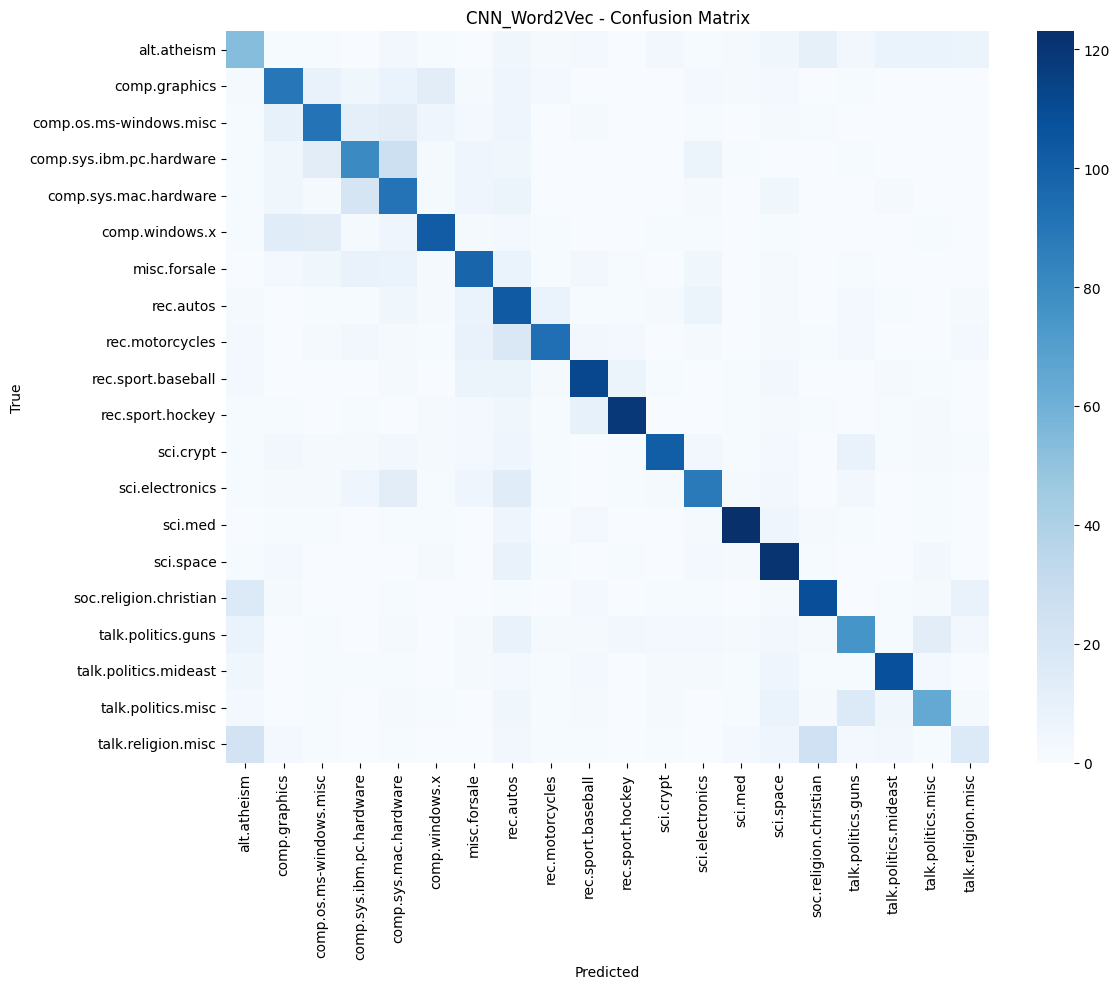


=== Training GRU_Word2Vec ===
Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.0700 - loss: 2.9274 - val_accuracy: 0.1072 - val_loss: 2.7136
Epoch 2/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0716 - loss: 2.9510 - val_accuracy: 0.0732 - val_loss: 2.8893
Epoch 3/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1080 - loss: 2.8034 - val_accuracy: 0.1843 - val_loss: 2.5334
Epoch 4/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1261 - loss: 2.7374 - val_accuracy: 0.1486 - val_loss: 2.6470
Epoch 5/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1998 - loss: 2.4101 - val_accuracy: 0.2706 - val_loss: 2.1085
Epoch 6/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2487 - loss: 2.1548 - val_accuracy: 0.2794 - val_loss: 2.0859
Epoch 7/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2735 - loss: 2.0530 - val_accuracy: 0.3343 - val_loss: 1.8602
Epoch 8/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3078 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


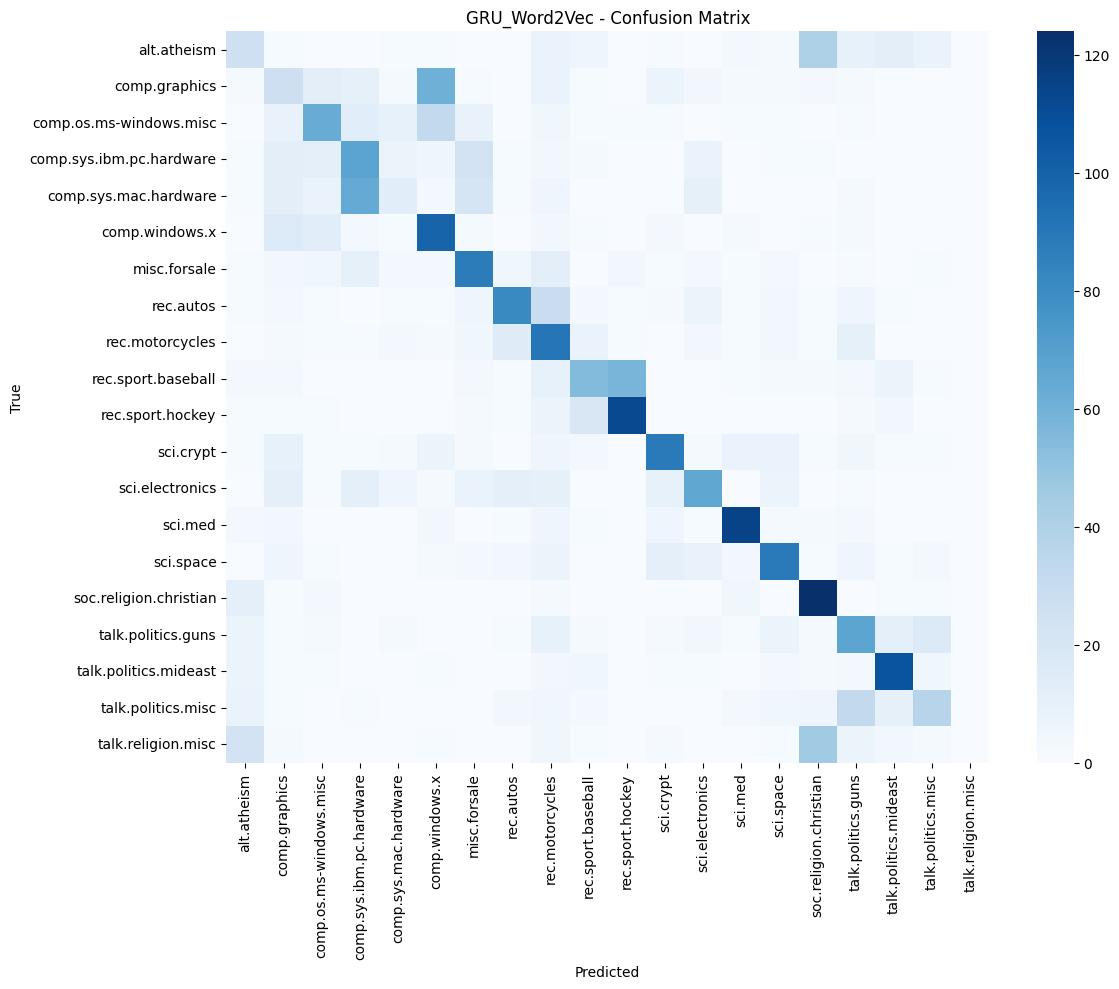


=== Training CNN_FastText ===
Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2993 - loss: 2.2371 - val_accuracy: 0.5462 - val_loss: 1.5424
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5498 - loss: 1.3969 - val_accuracy: 0.6148 - val_loss: 1.2555
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6505 - loss: 1.1047 - val_accuracy: 0.6364 - val_loss: 1.1615
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7179 - loss: 0.9054 - val_accuracy: 0.6487 - val_loss: 1.1226
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7731 - loss: 0.7393 - val_accuracy: 0.6572 - val_loss: 1.1304
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8224 - loss: 0.5892 - val_accuracy: 0.6523 - val_loss: 1.1683
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8633 - loss: 0.4671 - val_accuracy: 0.6434 - val_loss: 1.2614
Epoch 8/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8953 -

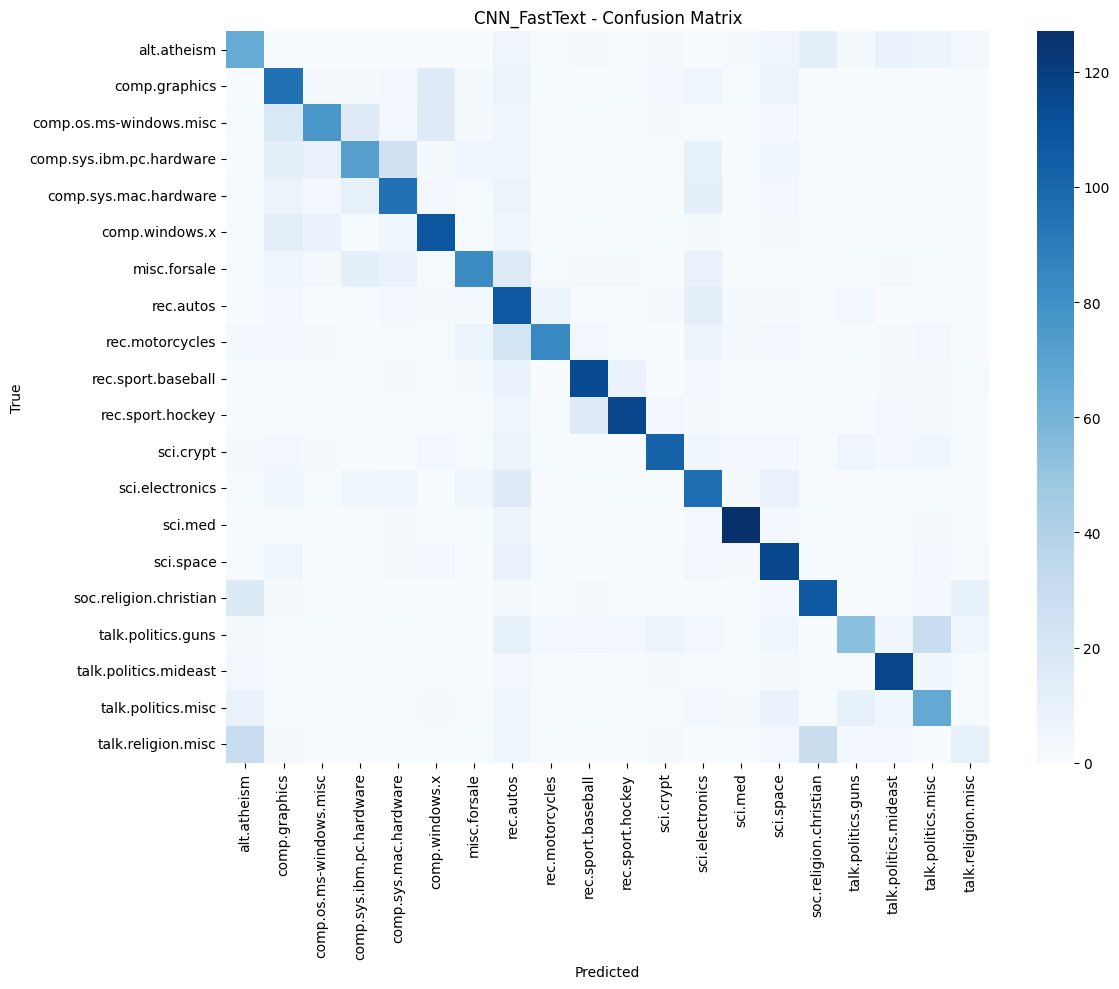


=== Training GRU_FastText ===
Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.0741 - loss: 2.9025 - val_accuracy: 0.0987 - val_loss: 2.7092
Epoch 2/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1106 - loss: 2.6295 - val_accuracy: 0.1411 - val_loss: 2.4702
Epoch 3/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1643 - loss: 2.3992 - val_accuracy: 0.2278 - val_loss: 2.2093
Epoch 4/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2228 - loss: 2.1706 - val_accuracy: 0.2879 - val_loss: 2.0535
Epoch 5/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2940 - loss: 1.9464 - val_accuracy: 0.3750 - val_loss: 1.7511
Epoch 6/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3593 - loss: 1.7568 - val_accuracy: 0.4163 - val_loss: 1.6246
Epoch 7/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3899 - loss: 1.6795 - val_accuracy: 0.4270 - val_loss: 1.6101
Epoch 8/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4200 - 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


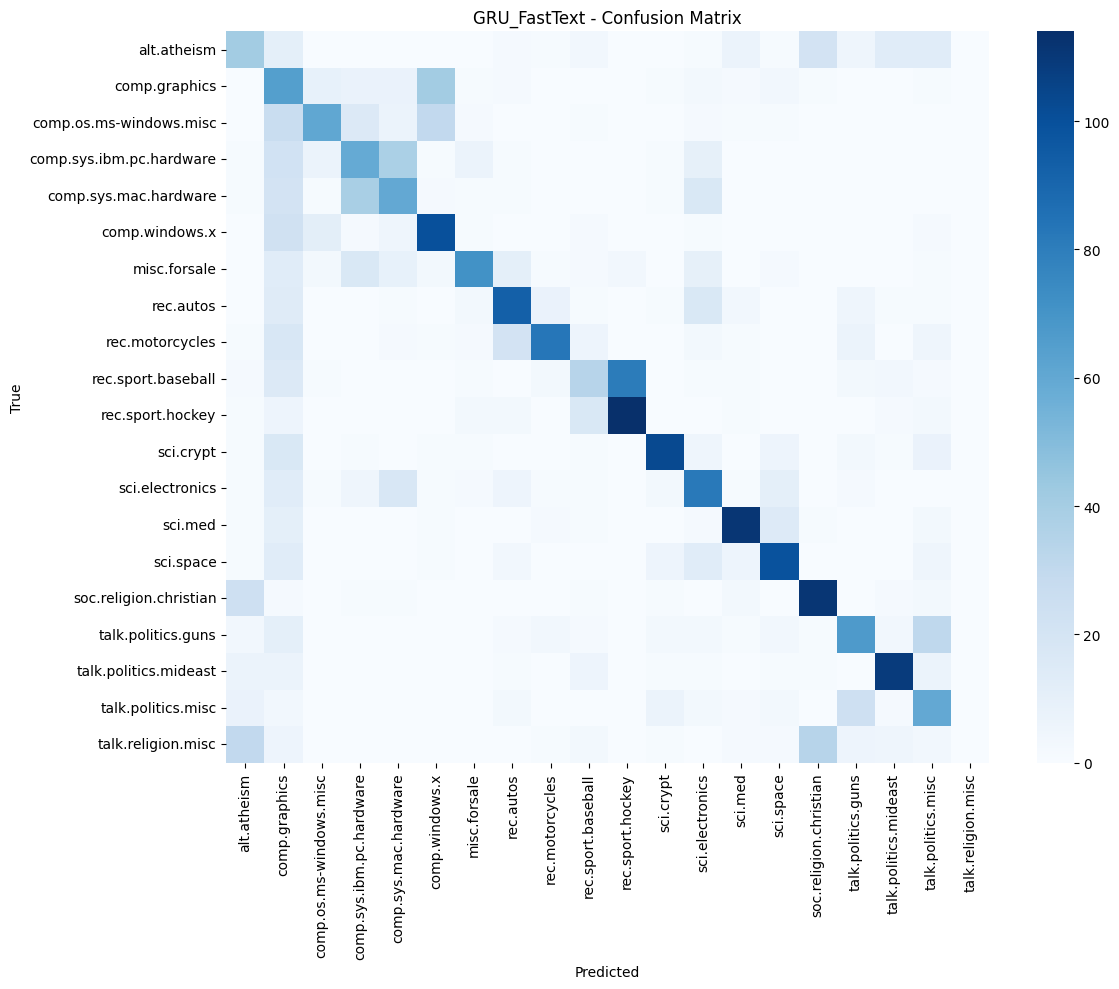

In [20]:
## ===== Task 5, Step 4: CNN + RNN with pretrained embeddings =====

embedding_configs = {
    'Word2Vec': embedding_matrix_w2v,
    'FastText': embedding_matrix_ft,
}

for emb_name, emb_matrix in embedding_configs.items():
    # --- CNN (uses Task 3's MAX_LEN=200 sequences) ---
    name = f"CNN_{emb_name}"
    print(f"\n=== Training {name} ===")
    model = build_cnn_pretrained(emb_matrix)
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val),
              epochs=10, batch_size=32, verbose=1)
    all_results[name] = evaluate_model(model, X_test_seq, y_test, target_names, name)

    # --- GRU (uses Task 4's best length, n=100) ---
    name = f"GRU_{emb_name}"
    print(f"\n=== Training {name} ===")
    model = build_rnn_pretrained(emb_matrix)
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    model.fit(X_train_n100, y_train, validation_data=(X_val_n100, y_val),
              epochs=15, batch_size=32, callbacks=[early_stop], verbose=1)
    all_results[name] = evaluate_model(model, X_test_n100, y_test, target_names, name)

**Step 05 : averaged-embedding ANN (Word2Vec, FastText as fixed document vectors**


Building averaged Word2Vec vectors...
=== Training ANN_Word2Vec ===
Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3354 - loss: 2.1013 - val_accuracy: 0.5529 - val_loss: 1.5006
Epoch 2/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5086 - loss: 1.5105 - val_accuracy: 0.5985 - val_loss: 1.3297
Epoch 3/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5616 - loss: 1.3708 - val_accuracy: 0.6194 - val_loss: 1.2710
Epoch 4/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5965 - loss: 1.2726 - val_accuracy: 0.6335 - val_loss: 1.2286
Epoch 5/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6141 - loss: 1.2111 - val_accuracy: 0.6300 - val_loss: 1.2098
Epoch 6/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6304 - loss: 1.1675 - val_accuracy: 0.6332 - val_loss: 1.2124
Epoch 7/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6427 - loss: 1.1318 - val_accuracy: 0.6388 - val_loss: 1.1944
Epoch 8/15
413/413 ━━━━━━━━━━━━━━━━

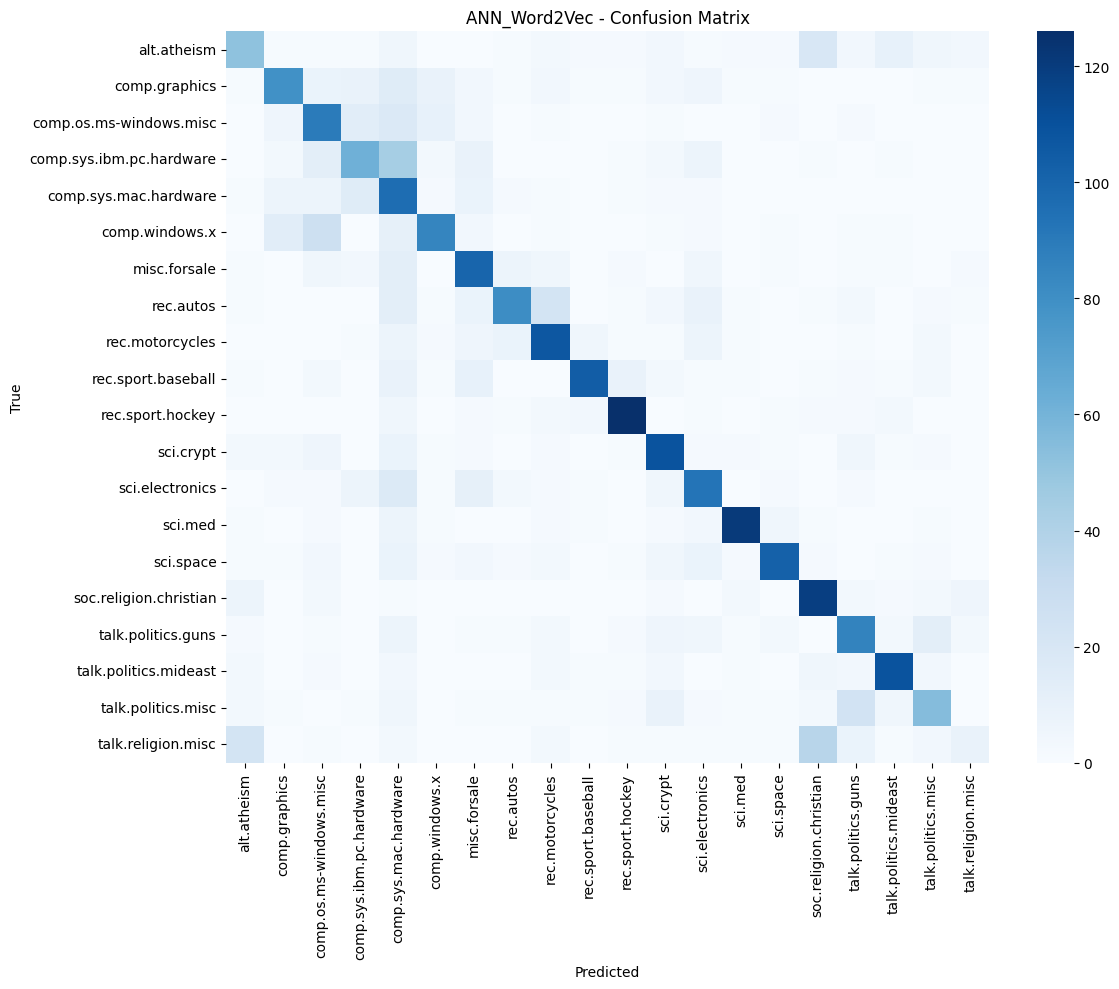


Building averaged FastText vectors...
=== Training ANN_FastText ===
Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2304 - loss: 2.4040 - val_accuracy: 0.4425 - val_loss: 1.8155
Epoch 2/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4197 - loss: 1.7363 - val_accuracy: 0.5451 - val_loss: 1.4853
Epoch 3/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5027 - loss: 1.5179 - val_accuracy: 0.5745 - val_loss: 1.3762
Epoch 4/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5391 - loss: 1.4171 - val_accuracy: 0.6006 - val_loss: 1.3160
Epoch 5/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5724 - loss: 1.3487 - val_accuracy: 0.6176 - val_loss: 1.2705
Epoch 6/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5872 - loss: 1.2898 - val_accuracy: 0.6314 - val_loss: 1.2483
Epoch 7/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6062 - loss: 1.2440 - val_accuracy: 0.6342 - val_loss: 1.2364
Epoch 8/15
413/413 ━━━━━━━━━━━━━━━━

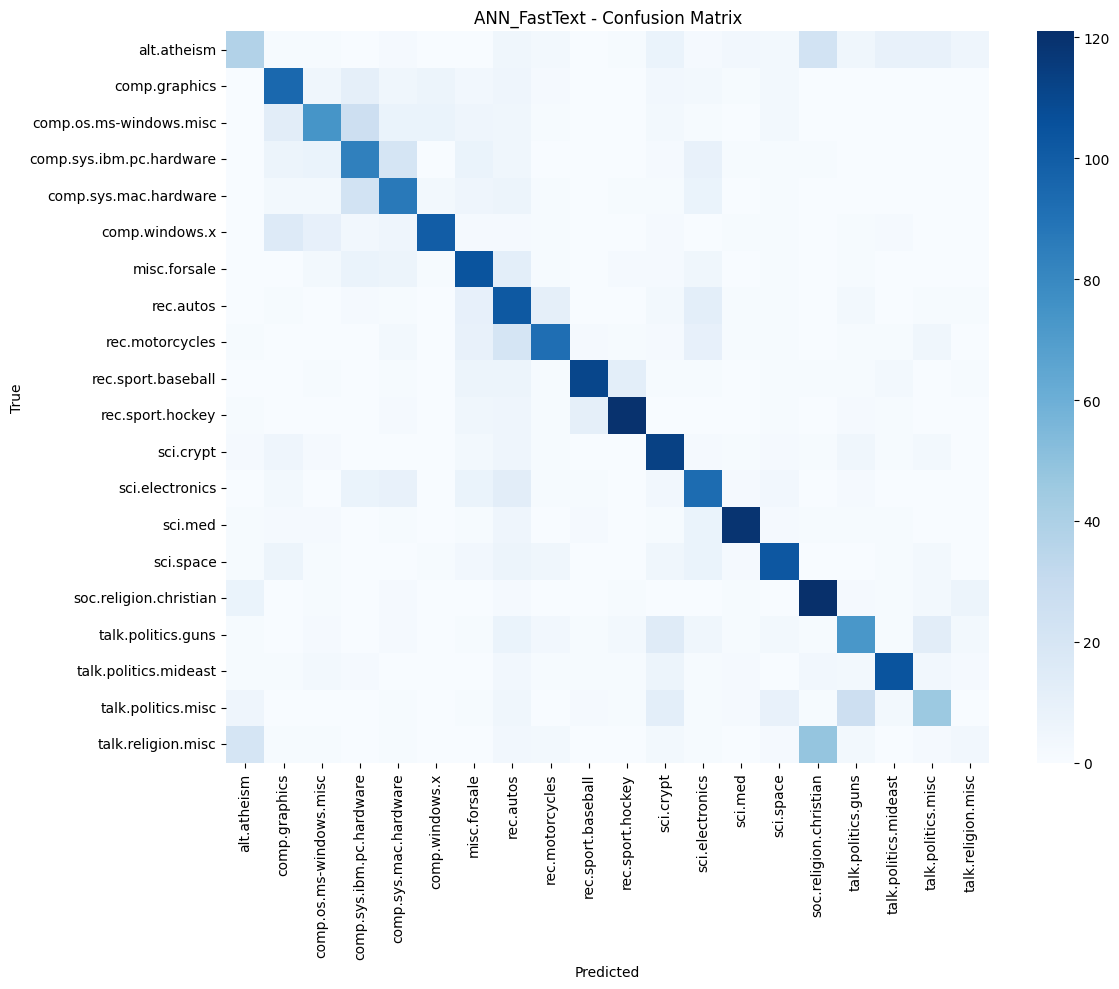

In [21]:
## ===== Task 5, Step 5: averaged embeddings for ANN =====

def average_embedding(docs, kv_model, dim=EMBED_DIM):
    """docs: list of cleaned strings (space-joined tokens, as in X_train/X_val/X_test)"""
    vectors = np.zeros((len(docs), dim))
    for i, doc in enumerate(docs):
        words = doc.split()
        word_vecs = [kv_model[w] for w in words if w in kv_model]
        if word_vecs:
            vectors[i] = np.mean(word_vecs, axis=0)
    return vectors

for emb_name, kv_model in [('Word2Vec', w2v_model), ('FastText', fasttext_model)]:
    print(f"\nBuilding averaged {emb_name} vectors...")
    X_train_avg = average_embedding(X_train, kv_model)
    X_val_avg   = average_embedding(X_val, kv_model)
    X_test_avg  = average_embedding(X_test, kv_model)

    name = f"ANN_{emb_name}"
    print(f"=== Training {name} ===")
    model = build_ann(input_dim=EMBED_DIM)
    model.fit(X_train_avg, y_train, validation_data=(X_val_avg, y_val),
              epochs=15, batch_size=32, verbose=1)
    all_results[name] = evaluate_model(model, X_test_avg, y_test, target_names, name)

## **Step 06 : extract frozen BERT document embeddings (mean-pooled)**

In [22]:
import pickle
with open('/kaggle/working/checkpoint_task5.pkl', 'wb') as f:
    pickle.dump(all_results, f)
print("saved", len(all_results), "results")

saved 25 results


In [24]:
import pickle, gc, torch

# safety copy of all results so far
with open('/kaggle/working/checkpoint_task5.pkl', 'wb') as f:
    pickle.dump(all_results, f)

gc.collect()
torch.cuda.empty_cache()

bert_encoder = bert_encoder.half()   # fp16: half the memory

def bert_embed(docs, batch_size=8):
    all_vecs = []
    with torch.no_grad():
        for i in range(0, len(docs), batch_size):
            batch = docs[i:i + batch_size]
            enc = bert_tokenizer(batch, padding=True, truncation=True,
                                 max_length=MAX_BERT_LEN, return_tensors="pt").to(device)
            out = bert_encoder(**enc).last_hidden_state.float()   # back to fp32 for pooling
            mask = enc["attention_mask"].unsqueeze(-1).float()
            mean = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
            all_vecs.append(mean.cpu().numpy())
    return np.vstack(all_vecs)

X_train_bert = bert_embed(X_train)
X_val_bert   = bert_embed(X_val)
X_test_bert  = bert_embed(X_test)
print(X_train_bert.shape, X_val_bert.shape, X_test_bert.shape)

(13192, 768) (2827, 768) (2827, 768)


## **Step 07 : train ANN on frozen BERT embeddings**

=== Training ANN_BERT ===
Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4141 - loss: 1.8451 - val_accuracy: 0.5950 - val_loss: 1.2674
Epoch 2/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5553 - loss: 1.3571 - val_accuracy: 0.6134 - val_loss: 1.1907
Epoch 3/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5877 - loss: 1.2493 - val_accuracy: 0.6204 - val_loss: 1.1649
Epoch 4/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6158 - loss: 1.1875 - val_accuracy: 0.6339 - val_loss: 1.1312
Epoch 5/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6286 - loss: 1.1287 - val_accuracy: 0.6406 - val_loss: 1.1284
Epoch 6/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6428 - loss: 1.0883 - val_accuracy: 0.6406 - val_loss: 1.1207
Epoch 7/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6562 - loss: 1.0437 - val_accuracy: 0.6434 - val_loss: 1.1209
Epoch 8/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6660 - loss:

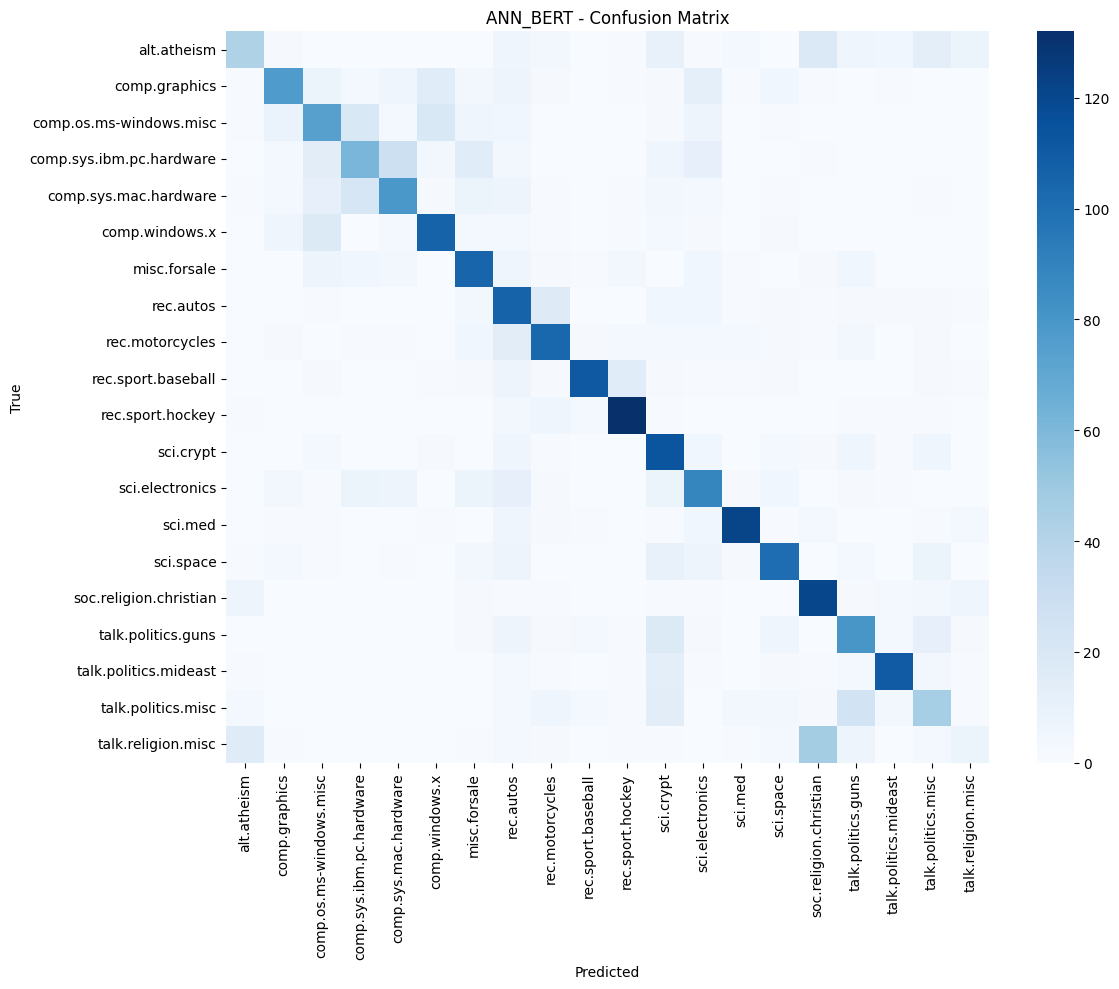

In [25]:
## ===== Task 5, Step 7: ANN on frozen BERT embeddings =====
print("=== Training ANN_BERT ===")
model = build_ann(input_dim=X_train_bert.shape[1])   # 768
model.fit(X_train_bert, y_train, validation_data=(X_val_bert, y_val),
          epochs=15, batch_size=32, verbose=1)
all_results['ANN_BERT'] = evaluate_model(model, X_test_bert, y_test, target_names, 'ANN_BERT')

# **Task 6: Transformer-based Model (Fine-tuned BERT)**



 Task 5's `ANN_BERT` used BERT as a *frozen* feature extractor — its 110M parameters never updated, so it produced the same general-purpose vectors regardless of what this specific classification task needed. That's exactly why it underperformed: BERT's pretrained knowledge (from Wikipedia + BookCorpus) doesn't naturally distinguish `sci.crypt` jargon from `talk.religion.misc` jargon — it just knows English.

**Fine-tuning** removes that limitation: instead of freezing BERT and training only a small classifier on top, we let gradients flow back through BERT itself, so its internal representations — built from stacked self-attention layers, where every token's representation is updated based on every other token in the sequence, not just a fixed local window like the CNN or a fixed recurrence like the RNN — get *adjusted* specifically for these 20 classes. This is the model family that assignment Task 7 will then test in *zero/one/few-shot* mode without any fine-tuning at all, so the contrast across Tasks 5→6→7 (frozen → fine-tuned → not-trained-at-all) tells a complete story about how much task-specific adaptation actually buys you.

We reuse the same `bert-base-uncased` checkpoint and `bert_tokenizer` from Task 5, but load a fresh model instance with a classification head (`AutoModelForSequenceClassification`) instead of the bare encoder used for frozen feature extraction.

## **Step 01 : imports + a PyTorch Dataset wrapper (needed because Trainer expects one):**

In [26]:
import pickle
import pandas as pd
from sklearn.metrics import f1_score

state = {
    'all_results': all_results,
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
    'target_names': target_names,
}
with open('/kaggle/working/state_after_task5.pkl', 'wb') as f:
    pickle.dump(state, f)

rows = [{'model': n, 'accuracy': round(r['accuracy'], 4),
         'macro_f1': round(f1_score(y_test, r['y_pred'], average='macro'), 4)}
        for n, r in all_results.items()]
summary = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
summary.to_csv('/kaggle/working/results_summary.csv', index=False)
print(len(all_results), "results saved")
print(summary.to_string(index=False))

26 results saved
         model  accuracy  macro_f1
     ANN_TFIDF    0.7007    0.6961
   CNN_k7_f128    0.6778    0.6719
    CNN_k3_f64    0.6654    0.6572
   CNN_k5_f128    0.6611    0.6567
  CNN_Word2Vec    0.6498    0.6390
  CNN_FastText    0.6403    0.6256
      ANN_BERT    0.6321    0.6111
  ANN_Word2Vec    0.6314    0.6183
  ANN_FastText    0.6307    0.6094
   BiLSTM_n100    0.5752    0.5534
    BiGRU_n100    0.5536    0.5255
  GRU_FastText    0.5387    0.5230
      GRU_n100    0.5090    0.4799
  GRU_Word2Vec    0.5016    0.4691
     LSTM_n100    0.4538    0.4158
    BiLSTM_n10    0.4362    0.4120
     BiGRU_n10    0.4199    0.4021
      LSTM_n10    0.4093    0.3752
 SimpleRNN_n10    0.3750    0.3509
       GRU_n10    0.3672    0.3320
      BiGRU_n5    0.3307    0.3121
     BiLSTM_n5    0.3247    0.3072
        GRU_n5    0.2989    0.2755
       LSTM_n5    0.2947    0.2753
  SimpleRNN_n5    0.2547    0.2288
SimpleRNN_n100    0.0651    0.0182


In [ ]:
import os
os._exit(0)

In [1]:
## ===== Task 6, Step 1: reload state + imports + Dataset wrapper =====
import os, pickle
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

assert os.path.exists('/kaggle/working/state_after_task5.pkl'), "state file missing - tell me"
with open('/kaggle/working/state_after_task5.pkl', 'rb') as f:
    state = pickle.load(f)

all_results  = state['all_results']
X_train, X_val, X_test = state['X_train'], state['X_val'], state['X_test']
y_train, y_val, y_test = state['y_train'], state['y_val'], state['y_test']
target_names = state['target_names']

RANDOM_STATE = 42
BERT_NAME = "bert-base-uncased"
MAX_BERT_LEN = 256
print("GPU:", torch.cuda.get_device_name(0), "| results loaded:", len(all_results))

class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(int(self.labels[idx]))
        return item

GPU: Tesla T4 | results loaded: 26


## **Step 02 : tokenize train/val/test (reuses bert_tokenizer from Task 5):**

In [2]:
## ===== Task 6, Step 2: tokenize =====
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)

def tokenize(texts):
    return bert_tokenizer(list(texts), truncation=True, padding='max_length', max_length=MAX_BERT_LEN)

train_ds = NewsDataset(tokenize(X_train), y_train)
val_ds   = NewsDataset(tokenize(X_val),   y_val)
test_ds  = NewsDataset(tokenize(X_test),  y_test)
print(len(train_ds), len(val_ds), len(test_ds))

13192 2827 2827


## **Step 03 : load BERT with a fresh classification head + metrics function:**

In [8]:
from transformers import logging
logging.set_verbosity_error()

In [9]:
## ===== Task 6, Step 3: model + metrics =====
torch.manual_seed(RANDOM_STATE)
model = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=len(target_names))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds),
            'macro_f1': f1_score(labels, preds, average='macro')}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [13]:
## ===== Task 6, Step 4: training config + Trainer =====
training_args = TrainingArguments(
    output_dir='/kaggle/working/bert_finetune',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=250,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    fp16=True,
    seed=RANDOM_STATE,
    logging_steps=100,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

## **Step 04 : training config + Trainer:**

In [14]:
## ===== Task 6, Step 3: model + metrics =====
torch.manual_seed(RANDOM_STATE)
model = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=len(target_names))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds),
            'macro_f1': f1_score(labels, preds, average='macro')}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [15]:
for name in ['model', 'train_ds', 'val_ds', 'training_args', 'trainer']:
    print(name, name in globals())

model True
train_ds True
val_ds True
training_args True
trainer True


## **Step 05 : fine-tune (the slow part — expect 15–30+ min on a Colab T4 GPU for 3 epochs):**

In [16]:
## ===== Task 6, Step 5: fine-tune =====
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '5.935', 'grad_norm': '15.18', 'learning_rate': '7.92e-06', 'epoch': '0.2421'}
{'loss': '4.89', 'grad_norm': '22.88', 'learning_rate': '1.592e-05', 'epoch': '0.4843'}
{'loss': '3.457', 'grad_norm': '12.7', 'learning_rate': '1.901e-05', 'epoch': '0.7264'}
{'loss': '2.796', 'grad_norm': '21.04', 'learning_rate': '1.699e-05', 'epoch': '0.9685'}
{'eval_loss': '2.417', 'eval_accuracy': '0.6502', 'eval_macro_f1': '0.6121', 'eval_runtime': '23.33', 'eval_samples_per_second': '121.2', 'eval_steps_per_second': '1.929', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '2.369', 'grad_norm': '13.3', 'learning_rate': '1.496e-05', 'epoch': '1.211'}
{'loss': '2.177', 'grad_norm': '13.04', 'learning_rate': '1.294e-05', 'epoch': '1.453'}
{'loss': '2.046', 'grad_norm': '16.6', 'learning_rate': '1.092e-05', 'epoch': '1.695'}
{'loss': '1.98', 'grad_norm': '16.88', 'learning_rate': '8.898e-06', 'epoch': '1.937'}
{'eval_loss': '1.976', 'eval_accuracy': '0.706', 'eval_macro_f1': '0.6826', 'eval_runtime': '23.35', 'eval_samples_per_second': '121.1', 'eval_steps_per_second': '1.927', 'epoch': '2'}


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '1.738', 'grad_norm': '19.08', 'learning_rate': '6.876e-06', 'epoch': '2.179'}
{'loss': '1.585', 'grad_norm': '19.15', 'learning_rate': '4.853e-06', 'epoch': '2.421'}
{'loss': '1.59', 'grad_norm': '25.86', 'learning_rate': '2.831e-06', 'epoch': '2.663'}
{'loss': '1.601', 'grad_norm': '19.35', 'learning_rate': '8.089e-07', 'epoch': '2.906'}
{'eval_loss': '1.909', 'eval_accuracy': '0.716', 'eval_macro_f1': '0.6962', 'eval_runtime': '23.32', 'eval_samples_per_second': '121.2', 'eval_steps_per_second': '1.929', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1045', 'train_samples_per_second': '37.85', 'train_steps_per_second': '1.185', 'train_loss': '2.644', 'epoch': '3'}


TrainOutput(global_step=1239, training_loss=2.64432528097847, metrics={'train_runtime': 1045.4964, 'train_samples_per_second': 37.854, 'train_steps_per_second': 1.185, 'train_loss': 2.64432528097847, 'epoch': 3.0})

In [22]:
num_train_epochs=6,
learning_rate=3e-5,
warmup_steps=150,

# **Step 6: evaluate on the test set**

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



BERT_finetuned — Test Accuracy: 0.7152

                          precision    recall  f1-score   support

             alt.atheism      0.481     0.542     0.510       120
           comp.graphics      0.699     0.685     0.692       146
 comp.os.ms-windows.misc      0.671     0.703     0.686       148
comp.sys.ibm.pc.hardware      0.615     0.653     0.634       147
   comp.sys.mac.hardware      0.825     0.653     0.729       144
          comp.windows.x      0.843     0.764     0.801       148
            misc.forsale      0.789     0.762     0.775       147
               rec.autos      0.489     0.772     0.599       149
         rec.motorcycles      0.763     0.773     0.768       150
      rec.sport.baseball      0.911     0.826     0.866       149
        rec.sport.hockey      0.893     0.893     0.893       150
               sci.crypt      0.766     0.750     0.758       148
         sci.electronics      0.647     0.669     0.658       148
                 sci.med      0.87

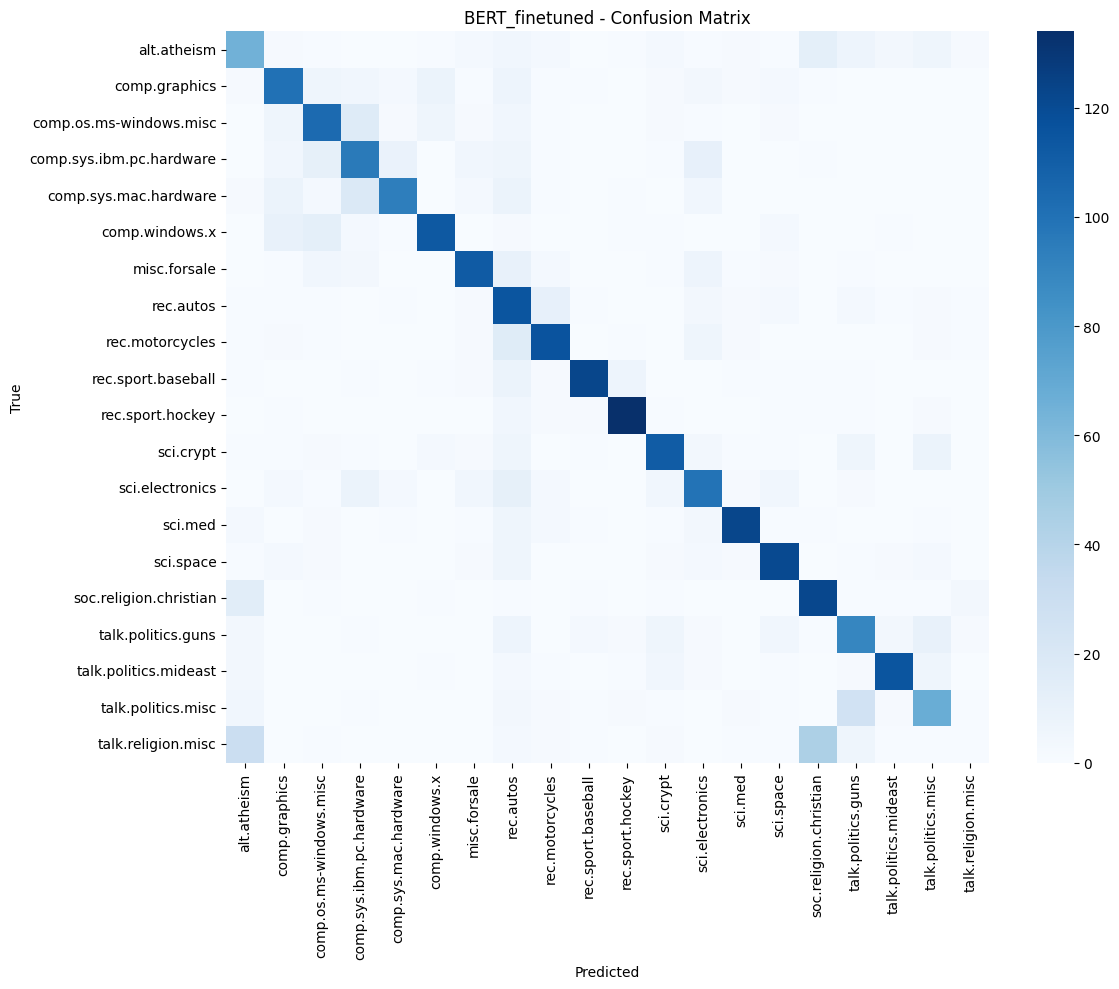

In [23]:
## ===== Task 6, Step 6: evaluate on test set =====
pred_out = trainer.predict(test_ds)
y_pred = np.argmax(pred_out.predictions, axis=1)
acc = accuracy_score(y_test, y_pred)
print(f"\nBERT_finetuned — Test Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('BERT_finetuned - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

all_results['BERT_finetuned'] = {'model': 'BERT_finetuned', 'accuracy': acc, 'y_pred': y_pred}

with open('/kaggle/working/state_after_task6.pkl', 'wb') as f:
    pickle.dump({'all_results': all_results,
                 'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
                 'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
                 'target_names': target_names}, f)

## **Step 6 - evaluate on test set, in the same confusion-matrix/classification-report style as every other task:**

# **TASK 7**

## **Step 1: free memory, load the sample and the shot examples**

In [24]:
## ===== Task 7, Step 1: setup =====
import gc, torch, numpy as np, pickle

for v in ['model', 'trainer']:
    if v in globals(): del globals()[v]
gc.collect(); torch.cuda.empty_cache()

X_te, X_tr = list(X_test), list(X_train)
y_te, y_tr = np.array(y_test), np.array(y_train)

rng = np.random.RandomState(42)
sub_idx = np.concatenate([rng.choice(np.where(y_te == c)[0], 25, replace=False) for c in range(20)])
rng.shuffle(sub_idx)
y_sub = y_te[sub_idx]

# 5 fixed training examples per class (the first one doubles as the one-shot example)
shots = {c: rng.choice(np.where(y_tr == c)[0], 5, replace=False) for c in range(20)}

LETTERS = list("ABCDEFGHIJKLMNOPQRST")

def short(t, n): return " ".join(t.split()[:n])

def build_prompt(doc, k):
    p = ("Classify each newsgroup post into one of these categories:\n"
         + "\n".join(f"{L}. {n}" for L, n in zip(LETTERS, target_names)) + "\n\n")
    if k > 0:
        items = [(c, j) for j in range(k) for c in range(20)]
        np.random.RandomState(7).shuffle(items)   # mixed order, fixed
        for c, j in items:
            p += f"Post: {short(X_tr[shots[c][j]], 40)}\nAnswer: {LETTERS[c]}\n\n"
    return p + f"Post: {short(doc, 150)}\nAnswer:"

print(len(sub_idx), "test docs |", np.bincount(y_sub).min(), "per class")
print("one-shot prompt words:", len(build_prompt(X_te[sub_idx[0]], 1).split()),
      "| few-shot:", len(build_prompt(X_te[sub_idx[0]], 5).split()))

500 test docs | 25 per class
one-shot prompt words: 834 | few-shot: 3211


## **Step 2: runner, then flan-t5-large zero-shot**

In [25]:
## ===== Task 7, Step 2: runner + flan-t5-large zero-shot =====
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSeq2SeqLM
from sklearn.metrics import accuracy_score, f1_score

@torch.no_grad()
def run_llm(tok, mdl, is_t5, k):
    if is_t5:
        letter_ids = [tok.encode(L, add_special_tokens=False)[0] for L in LETTERS]
    else:
        letter_ids = [tok.encode(" " + L, add_special_tokens=False)[0] for L in LETTERS]
    preds = []
    for n, i in enumerate(sub_idx):
        enc = tok(build_prompt(X_te[i], k), return_tensors='pt').to(mdl.device)
        if is_t5:
            dec = torch.tensor([[mdl.config.decoder_start_token_id]], device=mdl.device)
            logits = mdl(**enc, decoder_input_ids=dec).logits[0, -1]
        else:
            logits = mdl(**enc, logits_to_keep=1).logits[0, -1]
        preds.append(int(logits[letter_ids].argmax()))
        if (n + 1) % 100 == 0: print(f"  {n+1}/{len(sub_idx)}")
    preds = np.array(preds)
    return accuracy_score(y_sub, preds), f1_score(y_sub, preds, average='macro'), preds

def record(name, acc, f1, preds):
    all_results[name] = {'model': name, 'accuracy': acc, 'y_pred': preds, 'y_true': y_sub}
    print(f"{name}: acc={acc:.4f} macro_f1={f1:.4f}")
    with open('/kaggle/working/state_after_task7.pkl', 'wb') as f:
        pickle.dump({'all_results': all_results, 'sub_idx': sub_idx, 'target_names': target_names}, f)

t5_tok = AutoTokenizer.from_pretrained("google/flan-t5-large")
t5 = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-large").to('cuda').eval()   # fp32 on purpose

acc, f1, p = run_llm(t5_tok, t5, True, 0)
record('flan-t5-large_zeroshot', acc, f1, p)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  100/500
  200/500
  300/500
  400/500
  500/500
flan-t5-large_zeroshot: acc=0.4880 macro_f1=0.4855


## **Step 3: flan-t5 one-shot, then free the model**

In [26]:
## ===== Task 7, Step 3: flan-t5-large one-shot =====
acc, f1, p = run_llm(t5_tok, t5, True, 1)
record('flan-t5-large_oneshot', acc, f1, p)

del t5, t5_tok
gc.collect(); torch.cuda.empty_cache()

  100/500
  200/500
  300/500
  400/500
  500/500
flan-t5-large_oneshot: acc=0.3900 macro_f1=0.4026


## **Step 4: Qwen2.5-1.5B, all three scenarios**

In [27]:
## ===== Task 7, Step 4: Qwen2.5-1.5B-Instruct =====
q_name = "Qwen/Qwen2.5-1.5B-Instruct"
q_tok = AutoTokenizer.from_pretrained(q_name)
q = AutoModelForCausalLM.from_pretrained(q_name, torch_dtype=torch.float16).to('cuda').eval()

for k, tag in [(0, 'zeroshot'), (1, 'oneshot'), (5, 'fewshot5')]:
    print("Running", tag)
    acc, f1, p = run_llm(q_tok, q, False, k)
    record(f'Qwen2.5-1.5B_{tag}', acc, f1, p)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Running zeroshot
  100/500
  200/500
  300/500
  400/500
  500/500
Qwen2.5-1.5B_zeroshot: acc=0.1060 macro_f1=0.0877
Running oneshot
  100/500
  200/500
  300/500
  400/500
  500/500
Qwen2.5-1.5B_oneshot: acc=0.1320 macro_f1=0.0889
Running fewshot5
  100/500
  200/500
  300/500
  400/500
  500/500
Qwen2.5-1.5B_fewshot5: acc=0.2300 macro_f1=0.2019


## **metrics and confusion matrices**

This cell gives you the precision, recall and F1 for all five runs, a summary table, and a confusion matrix for each one. It also prints how many distinct classes each run predicted, to check the letter-bias idea.

                   run  accuracy  precision  recall  macro_f1  classes_predicted        most_common_pred
flan-t5-large_zeroshot     0.488     0.5658   0.488    0.4855                 18 comp.os.ms-windows.misc
 flan-t5-large_oneshot     0.390     0.6061   0.390    0.4026                 19             alt.atheism
 Qwen2.5-1.5B_zeroshot     0.106     0.2341   0.106    0.0877                 15           comp.graphics
  Qwen2.5-1.5B_oneshot     0.132     0.1922   0.132    0.0889                 15                 sci.med
 Qwen2.5-1.5B_fewshot5     0.230     0.2810   0.230    0.2019                 20      talk.politics.guns


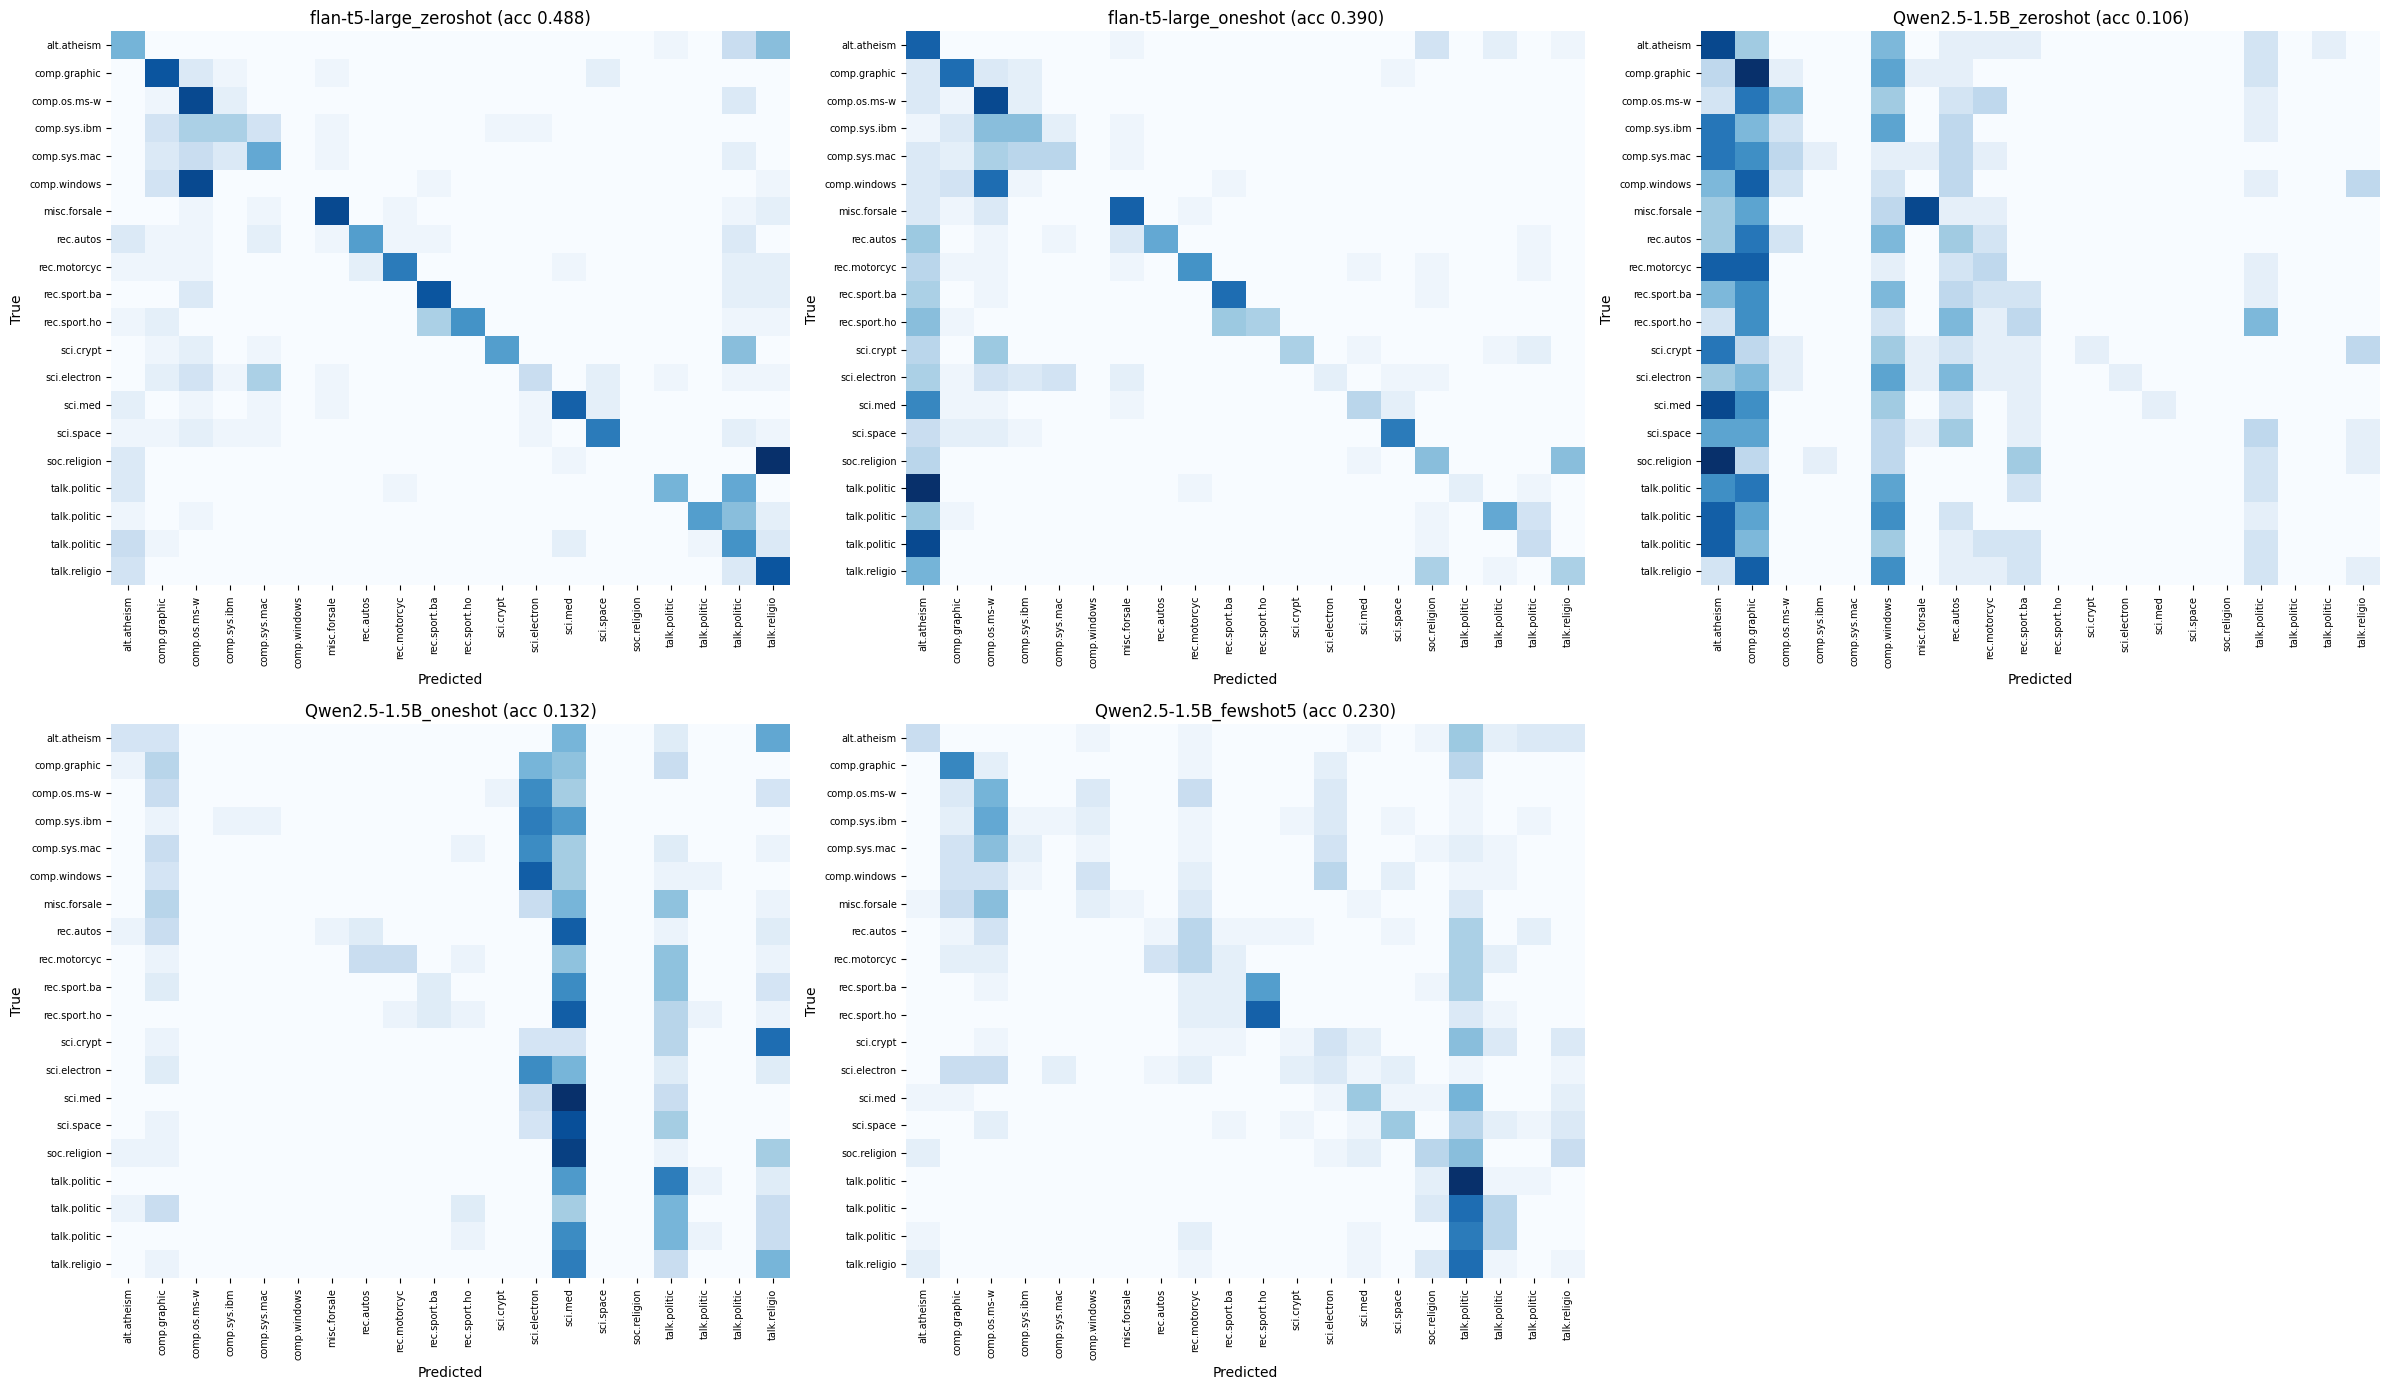

In [28]:
## ===== Task 7, Step 5: metrics + confusion matrices =====
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

llm_runs = [k for k in all_results if 'zeroshot' in k or 'oneshot' in k or 'fewshot' in k]
rows = []
for name in llm_runs:
    p = all_results[name]['y_pred']
    pr, rc, f1, _ = precision_recall_fscore_support(y_sub, p, average='macro', zero_division=0)
    rows.append({'run': name, 'accuracy': round(accuracy_score(y_sub, p), 4),
                 'precision': round(pr, 4), 'recall': round(rc, 4), 'macro_f1': round(f1, 4),
                 'classes_predicted': len(set(p)), 'most_common_pred': target_names[np.bincount(p).argmax()]})
llm_table = pd.DataFrame(rows)
print(llm_table.to_string(index=False))
llm_table.to_csv('/kaggle/working/llm_results.csv', index=False)

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
for ax, name in zip(axes.flat, llm_runs):
    cm = confusion_matrix(y_sub, all_results[name]['y_pred'], labels=range(20))
    sns.heatmap(cm, cmap='Blues', cbar=False, ax=ax,
                xticklabels=[t[:12] for t in target_names], yticklabels=[t[:12] for t in target_names])
    ax.set_title(f"{name} (acc {all_results[name]['accuracy']:.3f})")
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=90, labelsize=7); ax.tick_params(axis='y', labelsize=7)
for ax in axes.flat[len(llm_runs):]: ax.axis('off')
plt.tight_layout(); plt.savefig('/kaggle/working/llm_confusion.png', dpi=120); plt.show()

## **Step 6: Qwen with calibration**

# **Task 8**

## **Step 1: master table**

In [2]:
## ===== Task 8, Step 1: master results table =====
import pickle, numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# reload only if the session lost the variables
if 'all_results' not in globals() or 'y_test' not in globals():
    with open('/kaggle/working/state_after_task6.pkl', 'rb') as f: s6 = pickle.load(f)
    with open('/kaggle/working/state_after_task7.pkl', 'rb') as f: s7 = pickle.load(f)
    y_test, target_names = s6['y_test'], s6['target_names']
    all_results = s7['all_results']

def family(n):
    if 'flan' in n or 'Qwen' in n: return 'LLM'
    if 'finetuned' in n: return 'Transformer (fine-tuned)'
    return n.split('_')[0]

rows = []
for name, r in all_results.items():
    y_true = r.get('y_true', np.array(y_test))          # LLM runs carry their 500-doc labels
    p = np.array(r['y_pred'])
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, p, average='macro', zero_division=0)
    rows.append({'model': name, 'family': family(name),
                 'test_set': f"{len(y_true)} docs",
                 'accuracy': round(accuracy_score(y_true, p), 4),
                 'precision': round(pr, 4), 'recall': round(rc, 4), 'macro_f1': round(f1, 4)})

master = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
master.to_csv('/kaggle/working/master_results.csv', index=False)
print(master.to_string(index=False))

                 model                   family  test_set  accuracy  precision  recall  macro_f1
        BERT_finetuned Transformer (fine-tuned) 2827 docs    0.7152     0.6956  0.6990    0.6929
             ANN_TFIDF                      ANN 2827 docs    0.7007     0.7084  0.6925    0.6961
           CNN_k7_f128                      CNN 2827 docs    0.6778     0.6818  0.6688    0.6719
            CNN_k3_f64                      CNN 2827 docs    0.6654     0.6695  0.6551    0.6572
           CNN_k5_f128                      CNN 2827 docs    0.6611     0.6791  0.6523    0.6567
          CNN_Word2Vec                      CNN 2827 docs    0.6498     0.6510  0.6379    0.6390
          CNN_FastText                      CNN 2827 docs    0.6403     0.6439  0.6284    0.6256
              ANN_BERT                      ANN 2827 docs    0.6321     0.6219  0.6165    0.6111
          ANN_Word2Vec                      ANN 2827 docs    0.6314     0.6405  0.6181    0.6183
          ANN_FastText        

## **Step 2: plots**

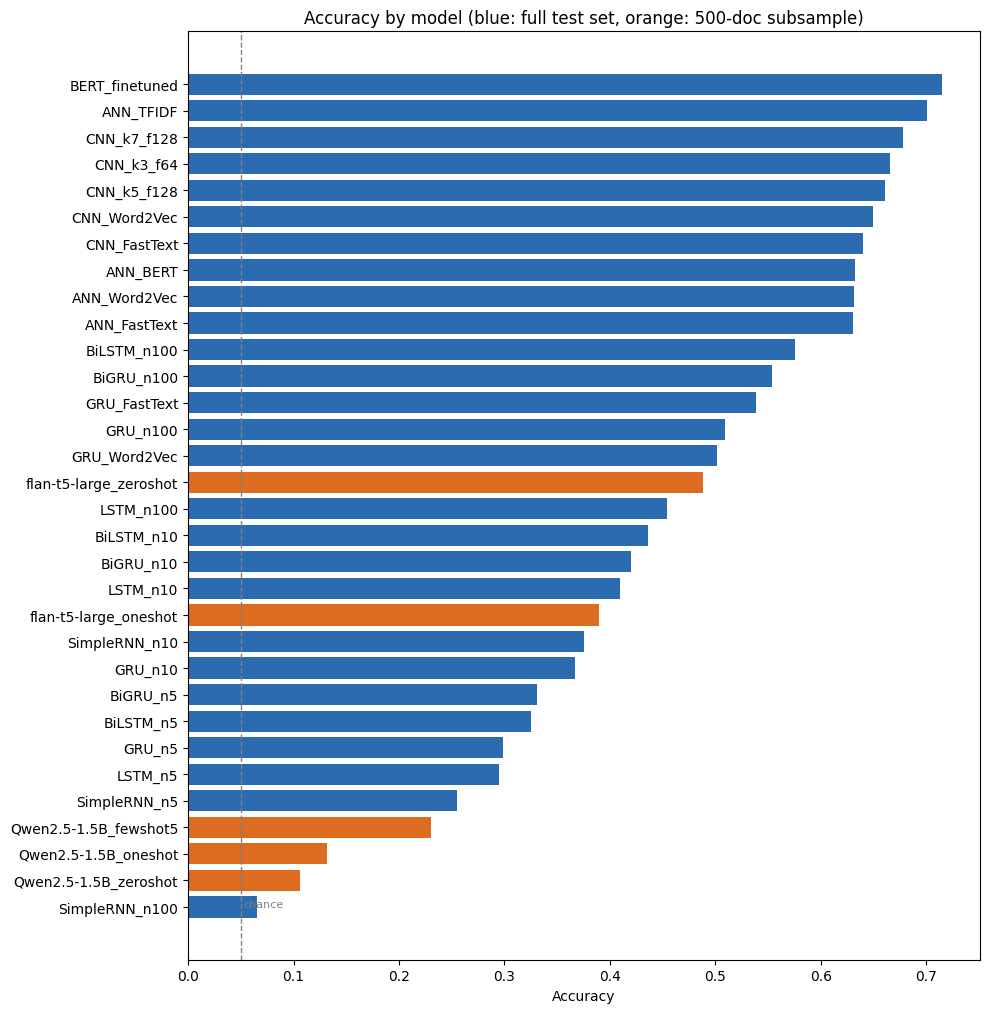

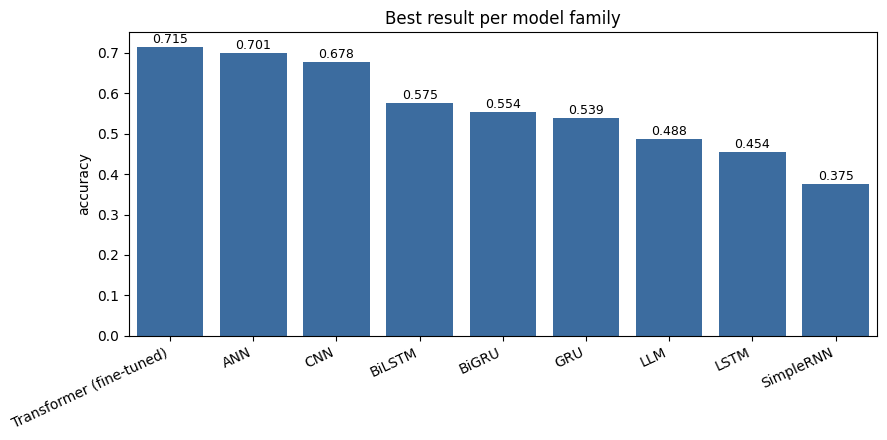

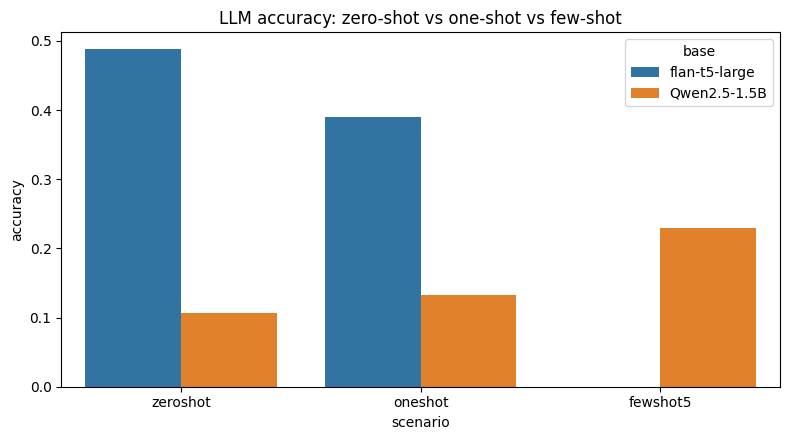

In [3]:
## ===== Task 8, Step 2: plots =====
import matplotlib.pyplot as plt, seaborn as sns

# 1) accuracy of every model, colored by test-set size
fig, ax = plt.subplots(figsize=(10, max(6, 0.32 * len(master))))
colors = master['test_set'].map({'2827 docs': '#2b6cb0', '500 docs': '#dd6b20'})
ax.barh(master['model'][::-1], master['accuracy'][::-1], color=colors[::-1])
ax.axvline(0.05, color='gray', ls='--', lw=1); ax.text(0.052, 0, 'chance', fontsize=8, color='gray')
ax.set_xlabel('Accuracy'); ax.set_title('Accuracy by model (blue: full test set, orange: 500-doc subsample)')
plt.tight_layout(); plt.savefig('/kaggle/working/accuracy_by_model.png', dpi=130); plt.show()

# 2) best model per family
best = master.loc[master.groupby('family')['accuracy'].idxmax()].sort_values('accuracy', ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=best, x='family', y='accuracy', ax=ax, color='#2b6cb0')
for i, v in enumerate(best['accuracy']): ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)
ax.set_title('Best result per model family'); ax.set_xlabel(''); plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.savefig('/kaggle/working/best_per_family.png', dpi=130); plt.show()

# 3) LLM scenarios: zero vs one vs few shot
llm = master[master['family'] == 'LLM'].copy()
llm['scenario'] = llm['model'].str.extract(r'(zeroshot|oneshot|fewshot5)')[0]
llm['base'] = llm['model'].str.replace(r'_(zeroshot|oneshot|fewshot5).*', '', regex=True)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=llm, x='scenario', y='accuracy', hue='base', ax=ax,
            order=['zeroshot', 'oneshot', 'fewshot5'])
ax.set_title('LLM accuracy: zero-shot vs one-shot vs few-shot'); plt.tight_layout()
plt.savefig('/kaggle/working/llm_scenarios.png', dpi=130); plt.show()

# **Testing Phase**

## **Cell 1: load the model and cleaning function**

In [4]:
## ===== Live test: setup =====
import os, glob, re, string, pickle, numpy as np, torch
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from transformers import AutoTokenizer, AutoModelForSequenceClassification

nltk.download('stopwords', quiet=True); nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
STOPWORDS = set(stopwords.words('english'))

def preprocess(text):                      # identical to your Task 1 function
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}0-9]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

with open('/kaggle/working/state_after_task6.pkl', 'rb') as f:
    target_names = pickle.load(f)['target_names']

ckpts = sorted(glob.glob('/kaggle/working/bert_finetune/checkpoint-*'),
               key=lambda p: int(p.split('-')[-1]))
print("checkpoints found:", ckpts)
ckpt = ckpts[-1]

bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")   # tokenizer was not saved in the checkpoint
bert_clf = AutoModelForSequenceClassification.from_pretrained(ckpt).to('cuda').eval()
print("loaded", ckpt)

checkpoints found: ['/kaggle/working/bert_finetune/checkpoint-1239']


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

loaded /kaggle/working/bert_finetune/checkpoint-1239


## **Cell 2: classify any text**

In [5]:
## ===== Live test: predict =====
@torch.no_grad()
def classify(text, top=3):
    clean = " ".join(preprocess(text))
    enc = bert_tok(clean, truncation=True, max_length=256, return_tensors='pt').to('cuda')
    probs = torch.softmax(bert_clf(**enc).logits[0].float(), dim=-1).cpu().numpy()
    print(f"cleaned: {clean[:120]}...")
    for i in probs.argsort()[::-1][:top]:
        print(f"  {probs[i]:.2f}  {target_names[i]}")
    print()

classify("The Yankees traded their closing pitcher after a rough inning last night.")
classify("My graphics card driver crashes every time I launch the game on Windows.")
classify("Does anyone know a good treatment for a persistent migraine headache?")
classify("I don't believe in any god, and the arguments for religion don't convince me.")

cleaned: yankees traded closing pitcher rough inning last night...
  0.95  rec.sport.baseball
  0.01  rec.sport.hockey
  0.00  talk.politics.misc

cleaned: graphics card driver crashes every time launch game windows...
  0.71  comp.os.ms-windows.misc
  0.10  comp.sys.ibm.pc.hardware
  0.06  comp.graphics

cleaned: anyone know good treatment persistent migraine headache...
  0.95  sci.med
  0.01  talk.politics.misc
  0.01  rec.sport.baseball

cleaned: believe god arguments religion convince...
  0.51  alt.atheism
  0.26  talk.religion.misc
  0.15  soc.religion.christian

